# 05a — Allocator diagnostics before frozen test

This notebook diagnoses whether the current detectability term is scientifically informative **before** the full frozen test experiment is launched.

It does **not** tune on the test split and does **not** overwrite the frozen payload grid.

It checks:

1. held-out discrimination of the auxiliary image detector;
2. paired detector change \(s(\mathrm{stego})-s(\mathrm{cover})\) for every \(\alpha\);
3. whether increasing \(\alpha\) really changes the selected blocks in the expected direction;
4. block-selection overlap between \(\alpha\) values;
5. whether local block risk \(D_i\) transfers to image-level detectability.

Interpretation rule: a mean detector output near 0.5 is **not** by itself evidence of random performance. ROC-AUC and paired cover/stego scores must be examined.


In [1]:
from pathlib import Path
import json, joblib, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdhlab.io import read_gray
from rdhlab.pipeline import (
    load_payload_freeze,
    run_frozen_image,
    score_aux_image_detector,
    prepare_image_context,
    deterministic_seed,
)
from rdhlab.blockcodec import embed_blockwise_net
from rdhlab.detectors import detector_metrics, paired_detector_bootstrap
from rdhlab.statistics import bootstrap_ci

config = yaml.safe_load(Path('/workspace/config/experiment.yaml').read_text())
seed = int(config['project']['seed'])
bs = int(config['dataset']['block_size'])

manifest = pd.read_csv(config['dataset']['prepared_manifest'])
train = manifest[manifest.split == 'train'].reset_index(drop=True)
val = manifest[manifest.split == 'validation'].reset_index(drop=True)

risk = joblib.load('/workspace/results/models/block_risk.joblib')
aux = joblib.load('/workspace/results/models/aux_image_detector.joblib')

payload_freeze = load_payload_freeze('/workspace/config/frozen_payloads.json')
levels = list(map(float, payload_freeze['levels']))
idx = min(int(config['allocator']['tune_payload_index']), len(levels) - 1)
tune_bpp = levels[idx]
alpha_grid = list(map(float, config['allocator']['alpha_grid']))
fixed_fpr = float(config['detectors']['fixed_fpr'])

diag_dir = Path('/workspace/results/diagnostics')
diag_dir.mkdir(parents=True, exist_ok=True)

print('Validation images:', len(val))
print('Frozen payload levels:', levels)
print('Diagnostic payload:', tune_bpp, 'net bpp')
print('Alpha grid:', alpha_grid)


Validation images: 2000
Frozen payload levels: [0.003, 0.006, 0.009, 0.012]
Diagnostic payload: 0.006 net bpp
Alpha grid: [0.0, 0.25, 0.5, 0.75, 1.0]


## 1. Held-out auxiliary-detector quality

The auxiliary detector was trained on the **train** split in notebook 05.  
Here it is evaluated on unseen **validation** images.

To match its training distribution, the validation stego set uses a deterministic mixture of:

- raster,
- random,
- predictability,
- detectability.

The experimental unit is the source image, therefore confidence intervals are obtained with a **paired image bootstrap**.


In [2]:
strategies = ['raster', 'random', 'predictability', 'detectability']
val_n = min(int(config['allocator']['validation_images']), len(val))

cover_scores = []
mixture_stego_scores = []
heldout_rows = []

for j, row in val.head(val_n).iterrows():
    x = read_gray(row.path)
    strategy = strategies[j % len(strategies)]
    rr = run_frozen_image(
        x, str(row.source_id), tune_bpp, strategy,
        risk, 0.5, bs, seed
    )
    if not rr['feasible']:
        continue

    sc = score_aux_image_detector(aux, x)
    ss = score_aux_image_detector(aux, rr['stego'])

    cover_scores.append(sc)
    mixture_stego_scores.append(ss)
    heldout_rows.append({
        'source_id': str(row.source_id),
        'strategy': strategy,
        'cover_score': sc,
        'stego_score': ss,
        'delta_score': ss - sc,
        'psnr': rr['psnr'],
    })

    if (j + 1) % 250 == 0:
        print('held-out detector', j + 1, '/', val_n)

heldout = pd.DataFrame(heldout_rows)
heldout.to_csv(diag_dir / 'aux_detector_heldout_pairs.csv', index=False)

c = np.asarray(cover_scores, dtype=float)
s = np.asarray(mixture_stego_scores, dtype=float)
y = np.tile([0, 1], len(c))
scores = np.column_stack([c, s]).reshape(-1)

heldout_metrics = detector_metrics(y, scores, fixed_fpr=fixed_fpr)
heldout_ci = paired_detector_bootstrap(
    c, s,
    fixed_fpr=fixed_fpr,
    n_resamples=int(config['statistics']['cluster_bootstrap_resamples']),
    confidence=float(config['statistics']['confidence']),
    seed=seed
)
delta_ci = bootstrap_ci(
    s - c,
    statistic='median',
    confidence=float(config['statistics']['confidence']),
    n_resamples=int(config['statistics']['bootstrap_resamples']),
    seed=seed
)

summary = {
    **heldout_metrics,
    **heldout_ci,
    'median_paired_delta': float(np.median(s-c)),
    'mean_paired_delta': float(np.mean(s-c)),
    'paired_delta_median_ci': delta_ci,
    'cover_score_mean': float(np.mean(c)),
    'stego_score_mean': float(np.mean(s)),
}

(diag_dir / 'aux_detector_heldout_summary.json').write_text(
    json.dumps(summary, indent=2),
    encoding='utf-8'
)

display(pd.DataFrame([summary]).drop(columns=['paired_delta_median_ci']))
print('Paired delta median CI:', delta_ci)


held-out detector 250 / 2000
held-out detector 500 / 2000
held-out detector 750 / 2000
held-out detector 1000 / 2000
held-out detector 1250 / 2000
held-out detector 1500 / 2000
held-out detector 1750 / 2000
held-out detector 2000 / 2000


,auc,tpr_at_fpr,fixed_fpr,n,auc_low,auc_high,tpr_low,tpr_high,n_pairs,bootstrap_resamples,confidence,median_paired_delta,mean_paired_delta,cover_score_mean,stego_score_mean
0,0.50372,0.052843,0.05,3974,0.503773,0.504148,0.050327,0.05536,1987,2000,0.95,0.000045,0.00005,0.499657,0.499708


Paired delta median CI: {'estimate': 4.506956723709932e-05, 'low': 4.3704067939298596e-05, 'high': 4.6543705976564986e-05, 'n': 1987}


### Reading this result

A useful auxiliary risk model should show discrimination above chance on held-out data.  
The exact AUC required is not predeclared here; the purpose is diagnostic.

AUC close to 0.5 would mean that the current auxiliary detector provides little evidence that its score is a meaningful image-level detectability proxy.


## 2. Paired alpha diagnostics

For each validation image and every \(\alpha\), compute:

\[
\Delta_j(\alpha)=s(Y_{j,\alpha})-s(X_j).
\]

This is more informative than comparing the absolute mean stego probability because each stego image is paired with its own cover.

The same run records:

- PSNR;
- selected-block mean predictability;
- selected-block mean detectability risk;
- feasibility.


In [3]:
alpha_rows = []
pair_rows = []

for alpha in alpha_grid:
    n_feasible = 0
    for j, row in val.head(val_n).iterrows():
        x = read_gray(row.path)
        rr = run_frozen_image(
            x, str(row.source_id), tune_bpp, 'joint',
            risk, alpha, bs, seed
        )
        if not rr['feasible']:
            pair_rows.append({
                'source_id': str(row.source_id),
                'alpha': alpha,
                'feasible': False,
            })
            continue

        n_feasible += 1
        sc = score_aux_image_detector(aux, x)
        ss = score_aux_image_detector(aux, rr['stego'])

        pair_rows.append({
            'source_id': str(row.source_id),
            'alpha': alpha,
            'feasible': True,
            'cover_score': sc,
            'stego_score': ss,
            'delta_score': ss - sc,
            'psnr': rr['psnr'],
            'ssim': rr['ssim'],
            'selected_predictability_mean': rr['selected_predictability_mean'],
            'selected_detectability_risk_mean': rr['selected_detectability_risk_mean'],
            'used_blocks': rr['used_blocks'],
        })

        if (j + 1) % 500 == 0:
            print('alpha', alpha, j + 1, '/', val_n)

pairs = pd.DataFrame(pair_rows)
pairs.to_csv(diag_dir / 'allocator_alpha_paired_validation.csv', index=False)

for alpha in alpha_grid:
    z = pairs[(pairs.alpha == alpha) & (pairs.feasible == True)].copy()
    if z.empty:
        continue

    cc = z.cover_score.to_numpy(float)
    ss = z.stego_score.to_numpy(float)
    yy = np.tile([0, 1], len(z))
    score_pair = np.column_stack([cc, ss]).reshape(-1)

    m = detector_metrics(yy, score_pair, fixed_fpr=fixed_fpr)
    ci = paired_detector_bootstrap(
        cc, ss,
        fixed_fpr=fixed_fpr,
        n_resamples=int(config['statistics']['cluster_bootstrap_resamples']),
        confidence=float(config['statistics']['confidence']),
        seed=seed + int(round(alpha * 1000))
    )
    dci = bootstrap_ci(
        z.delta_score.to_numpy(float),
        statistic='median',
        confidence=float(config['statistics']['confidence']),
        n_resamples=int(config['statistics']['bootstrap_resamples']),
        seed=seed + 100 + int(round(alpha * 1000))
    )

    alpha_rows.append({
        'alpha': alpha,
        'n': val_n,
        'n_feasible': len(z),
        'feasible_fraction': len(z) / val_n,
        'cover_score_mean': z.cover_score.mean(),
        'stego_score_mean': z.stego_score.mean(),
        'delta_mean': z.delta_score.mean(),
        'delta_median': z.delta_score.median(),
        'delta_median_ci_low': dci['low'],
        'delta_median_ci_high': dci['high'],
        'auc': m['auc'],
        'auc_ci_low': ci['auc_low'],
        'auc_ci_high': ci['auc_high'],
        'tpr_at_5pct_fpr': m['tpr_at_fpr'],
        'tpr_ci_low': ci['tpr_low'],
        'tpr_ci_high': ci['tpr_high'],
        'psnr_mean': z.psnr.mean(),
        'ssim_mean': z.ssim.mean(),
        'selected_P_mean': z.selected_predictability_mean.mean(),
        'selected_D_mean': z.selected_detectability_risk_mean.mean(),
        'used_blocks_mean': z.used_blocks.mean(),
    })

alpha_diag = pd.DataFrame(alpha_rows)
alpha_diag.to_csv(diag_dir / 'allocator_alpha_diagnostics.csv', index=False)
display(alpha_diag)


alpha 0.0 500 / 2000
alpha 0.0 1000 / 2000
alpha 0.0 1500 / 2000
alpha 0.0 2000 / 2000
alpha 0.25 500 / 2000
alpha 0.25 1000 / 2000
alpha 0.25 1500 / 2000
alpha 0.25 2000 / 2000
alpha 0.5 500 / 2000
alpha 0.5 1000 / 2000
alpha 0.5 1500 / 2000
alpha 0.5 2000 / 2000
alpha 0.75 500 / 2000
alpha 0.75 1000 / 2000
alpha 0.75 1500 / 2000
alpha 0.75 2000 / 2000
alpha 1.0 500 / 2000
alpha 1.0 1000 / 2000
alpha 1.0 1500 / 2000
alpha 1.0 2000 / 2000


,alpha,n,n_feasible,feasible_fraction,cover_score_mean,stego_score_mean,delta_mean,delta_median,delta_median_ci_low,delta_median_ci_high,...,auc_ci_low,auc_ci_high,tpr_at_5pct_fpr,tpr_ci_low,tpr_ci_high,psnr_mean,ssim_mean,selected_P_mean,selected_D_mean,used_blocks_mean
0,0.00,2000,1987,0.9935,0.499657,0.499708,0.000050,0.000044,0.000043,0.000046,...,0.503650,0.504013,0.053347,0.050327,0.055863,58.489488,0.999777,0.337908,0.000887,5.322094
1,0.25,2000,1987,0.9935,0.499657,0.499708,0.000050,0.000044,0.000043,0.000045,...,0.503709,0.504067,0.053347,0.050327,0.055863,59.541878,0.999783,0.411779,0.000942,4.450931
2,0.50,2000,1987,0.9935,0.499657,0.499708,0.000051,0.000045,0.000044,0.000047,...,0.503799,0.504164,0.051837,0.050327,0.054857,60.894016,0.999787,0.479001,0.001247,3.406140
3,0.75,2000,1987,0.9935,0.499657,0.499708,0.000050,0.000045,0.000043,0.000046,...,0.503803,0.504164,0.051837,0.050327,0.054857,61.806977,0.999792,0.507300,0.001621,2.785103
4,1.00,2000,1987,0.9935,0.499657,0.499707,0.000050,0.000044,0.000043,0.000045,...,0.503803,0.504165,0.052340,0.050327,0.055360,62.301634,0.999801,0.514381,0.001906,2.506291


## 3. Direction check

With

\[
J_i=\alpha \widetilde P_i-(1-\alpha)\widetilde D_i,
\]

we expect:

- \(\alpha=0\): strongest preference for **low \(D_i\)**;
- \(\alpha=1\): strongest preference for **high \(P_i\)**.

Therefore `selected_D_mean` should generally increase as detectability receives less weight, while `selected_P_mean` should generally increase with \(\alpha\).

If this does not happen, the issue is likely in ranking or aggregation rather than in the detector itself.


In [4]:
direction = alpha_diag[
    ['alpha','selected_P_mean','selected_D_mean','delta_median','auc','psnr_mean','feasible_fraction']
].copy()
display(direction)

rho_alpha_P = direction[['alpha','selected_P_mean']].corr(method='spearman').iloc[0,1]
rho_alpha_D = direction[['alpha','selected_D_mean']].corr(method='spearman').iloc[0,1]

print('Spearman(alpha, selected_P_mean) =', rho_alpha_P)
print('Spearman(alpha, selected_D_mean) =', rho_alpha_D)


,alpha,selected_P_mean,selected_D_mean,delta_median,auc,psnr_mean,feasible_fraction
0,0.00,0.337908,0.000887,0.000044,0.503596,58.489488,0.9935
1,0.25,0.411779,0.000942,0.000044,0.503645,59.541878,0.9935
2,0.50,0.479001,0.001247,0.000045,0.503732,60.894016,0.9935
3,0.75,0.507300,0.001621,0.000045,0.503737,61.806977,0.9935
4,1.00,0.514381,0.001906,0.000044,0.503735,62.301634,0.9935


Spearman(alpha, selected_P_mean) = 1.0
Spearman(alpha, selected_D_mean) = 1.0


## 4. Selected-block overlap between alpha values

A diagnostic subset is used because this requires recovering the exact selected block IDs.

For each image, the Jaccard index is computed between the block sets selected under two \(\alpha\) values:

\[
J(A,B)=\frac{|A\cap B|}{|A\cup B|}.
\]

If overlap is almost 1 for all pairs, changing \(\alpha\) is not materially changing the allocation.


In [5]:
overlap_n = min(250, val_n)
overlap_rows = []

def selected_block_ids(image, source_id, alpha):
    orders, block_rows, plans = prepare_image_context(
        image, source_id, risk, alpha, bs, seed
    )
    target_net_bits = int(round(tune_bpp * image.size))
    rng = np.random.default_rng(
        deterministic_seed(seed, source_id, tune_bpp, 'joint')
    )
    try:
        _, _, meta, _ = embed_blockwise_net(
            image,
            target_net_bits,
            orders['joint'],
            rng,
            bs,
            plans=plans
        )
    except ValueError:
        return None
    return {u.block_id for u in meta.used_blocks}

for j, row in val.head(overlap_n).iterrows():
    x = read_gray(row.path)
    sets = {
        a: selected_block_ids(x, str(row.source_id), a)
        for a in alpha_grid
    }
    for ia, a in enumerate(alpha_grid):
        for b in alpha_grid[ia+1:]:
            A, B = sets[a], sets[b]
            if A is None or B is None:
                continue
            union = A | B
            jac = len(A & B) / len(union) if union else 1.0
            overlap_rows.append({
                'source_id': str(row.source_id),
                'alpha_a': a,
                'alpha_b': b,
                'jaccard': jac,
                'n_a': len(A),
                'n_b': len(B),
            })

    if (j + 1) % 50 == 0:
        print('overlap', j + 1, '/', overlap_n)

overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(diag_dir / 'allocator_alpha_block_overlap.csv', index=False)

overlap_summary = (
    overlap.groupby(['alpha_a','alpha_b'], as_index=False)
    .agg(
        jaccard_mean=('jaccard','mean'),
        jaccard_median=('jaccard','median'),
        n_images=('jaccard','size')
    )
)
display(overlap_summary)


overlap 50 / 250
overlap 100 / 250
overlap 150 / 250
overlap 200 / 250
overlap 250 / 250


,alpha_a,alpha_b,jaccard_mean,jaccard_median,n_images
0,0.00,0.25,0.678556,0.700000,249
1,0.00,0.50,0.405108,0.375000,249
2,0.00,0.75,0.250961,0.181818,249
3,0.00,1.00,0.175083,0.100000,249
4,0.25,0.50,0.610043,0.600000,249
5,0.25,0.75,0.406840,0.333333,249
6,0.25,1.00,0.305519,0.250000,249
7,0.50,0.75,0.678150,0.750000,249
8,0.50,1.00,0.513227,0.500000,249
9,0.75,1.00,0.755577,1.000000,249


## 5. Diagnostic figures


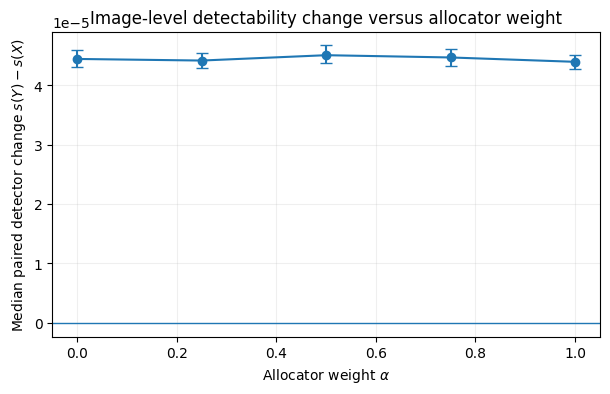

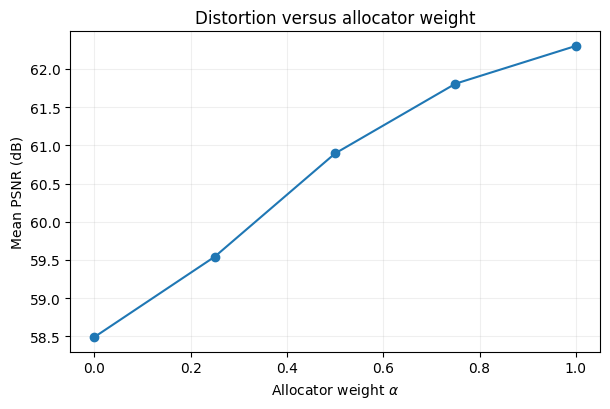

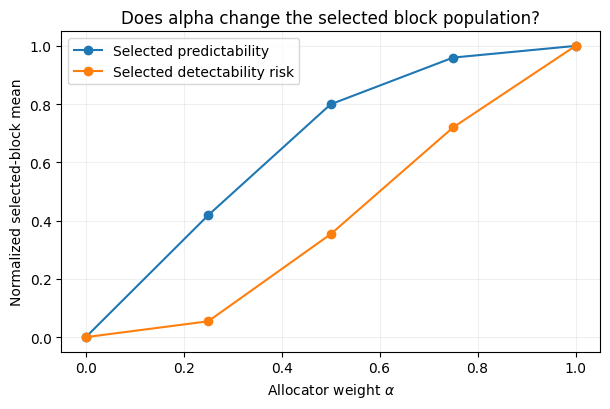

In [6]:
# Alpha vs paired detector change
fig, ax = plt.subplots(figsize=(6.2,4.2))
ax.errorbar(
    alpha_diag.alpha,
    alpha_diag.delta_median,
    yerr=[
        alpha_diag.delta_median - alpha_diag.delta_median_ci_low,
        alpha_diag.delta_median_ci_high - alpha_diag.delta_median
    ],
    marker='o',
    capsize=4
)
ax.axhline(0, linewidth=1)
ax.set_xlabel(r'Allocator weight $\alpha$')
ax.set_ylabel(r'Median paired detector change $s(Y)-s(X)$')
ax.set_title('Image-level detectability change versus allocator weight')
ax.grid(True, alpha=.2)
fig.tight_layout()
fig.savefig(diag_dir / 'alpha_vs_paired_delta.png', dpi=300)
plt.show()

# Alpha vs PSNR
fig, ax = plt.subplots(figsize=(6.2,4.2))
ax.plot(alpha_diag.alpha, alpha_diag.psnr_mean, marker='o')
ax.set_xlabel(r'Allocator weight $\alpha$')
ax.set_ylabel('Mean PSNR (dB)')
ax.set_title('Distortion versus allocator weight')
ax.grid(True, alpha=.2)
fig.tight_layout()
fig.savefig(diag_dir / 'alpha_vs_psnr.png', dpi=300)
plt.show()

# Selected P and D — standardized only for visualization
viz = alpha_diag[['alpha','selected_P_mean','selected_D_mean']].copy()
for c in ['selected_P_mean','selected_D_mean']:
    lo, hi = viz[c].min(), viz[c].max()
    viz[c+'_norm'] = 0 if hi <= lo else (viz[c]-lo)/(hi-lo)

fig, ax = plt.subplots(figsize=(6.2,4.2))
ax.plot(viz.alpha, viz.selected_P_mean_norm, marker='o', label='Selected predictability')
ax.plot(viz.alpha, viz.selected_D_mean_norm, marker='o', label='Selected detectability risk')
ax.set_xlabel(r'Allocator weight $\alpha$')
ax.set_ylabel('Normalized selected-block mean')
ax.set_title('Does alpha change the selected block population?')
ax.grid(True, alpha=.2)
ax.legend()
fig.tight_layout()
fig.savefig(diag_dir / 'alpha_selected_P_D.png', dpi=300)
plt.show()


## 6. Automatic diagnostic summary

This cell does **not** choose the final \(\alpha\).  
It only classifies the most likely failure mode to guide the next experiment.


In [7]:
auc = float(heldout_metrics['auc'])
delta_span = float(alpha_diag.delta_median.max() - alpha_diag.delta_median.min())
psnr_span = float(alpha_diag.psnr_mean.max() - alpha_diag.psnr_mean.min())
D_span = float(alpha_diag.selected_D_mean.max() - alpha_diag.selected_D_mean.min())
P_span = float(alpha_diag.selected_P_mean.max() - alpha_diag.selected_P_mean.min())
max_overlap = float(overlap_summary.jaccard_median.max()) if len(overlap_summary) else np.nan
min_overlap = float(overlap_summary.jaccard_median.min()) if len(overlap_summary) else np.nan

print('HELD-OUT AUX AUC:', auc)
print('Median paired-delta span across alpha:', delta_span)
print('PSNR span across alpha:', psnr_span, 'dB')
print('Selected-D span across alpha:', D_span)
print('Selected-P span across alpha:', P_span)
print('Median Jaccard overlap range:', (min_overlap, max_overlap))
print()

if auc < 0.55:
    print('DIAGNOSTIC: auxiliary detector is weak on held-out validation.')
    print('Do not use its D_i as the main scientific detectability proxy without redesign/retraining.')
elif D_span < 1e-6 and P_span < 1e-6:
    print('DIAGNOSTIC: changing alpha barely changes selected block statistics.')
    print('Inspect allocator ranking/normalization and block-order realization.')
elif abs(delta_span) < 1e-4 and psnr_span > 0.5:
    print('DIAGNOSTIC: allocation changes distortion, but local D_i does not transfer to image-level detector change.')
    print('This supports investigating local-to-global detectability mismatch or contextual/cumulative risk.')
else:
    print('DIAGNOSTIC: alpha produces measurable image-level detectability differences.')
    print('Proceed to validation-only selection only after reviewing CIs and independent detector results.')

diagnostic_summary = {
    'heldout_aux_auc': auc,
    'paired_delta_span': delta_span,
    'psnr_span_db': psnr_span,
    'selected_D_span': D_span,
    'selected_P_span': P_span,
    'median_jaccard_min': min_overlap,
    'median_jaccard_max': max_overlap,
    'note': 'Diagnostic only; no alpha is frozen by this notebook.'
}

(diag_dir / 'allocator_diagnostic_summary.json').write_text(
    json.dumps(diagnostic_summary, indent=2),
    encoding='utf-8'
)

diagnostic_summary


HELD-OUT AUX AUC: 0.5037203321337056
Median paired-delta span across alpha: 1.1156027622805098e-06
PSNR span across alpha: 3.8121453255378555 dB
Selected-D span across alpha: 0.0010197477965790467
Selected-P span across alpha: 0.1764731796660146
Median Jaccard overlap range: (0.1, 1.0)

DIAGNOSTIC: auxiliary detector is weak on held-out validation.
Do not use its D_i as the main scientific detectability proxy without redesign/retraining.


{'heldout_aux_auc': 0.5037203321337056,
 'paired_delta_span': 1.1156027622805098e-06,
 'psnr_span_db': 3.8121453255378555,
 'selected_D_span': 0.0010197477965790467,
 'selected_P_span': 0.1764731796660146,
 'median_jaccard_min': 0.1,
 'median_jaccard_max': 1.0,
 'note': 'Diagnostic only; no alpha is frozen by this notebook.'}

## Outputs

The notebook writes:

- `results/diagnostics/aux_detector_heldout_pairs.csv`
- `results/diagnostics/aux_detector_heldout_summary.json`
- `results/diagnostics/allocator_alpha_paired_validation.csv`
- `results/diagnostics/allocator_alpha_diagnostics.csv`
- `results/diagnostics/allocator_alpha_block_overlap.csv`
- `results/diagnostics/allocator_diagnostic_summary.json`
- three 300-dpi diagnostic figures.

**Do not launch the full frozen test solely on the basis of the old `aux_score_mean` table.**  
Use these diagnostics first.
